# Phase 4 — release, scoring, ranking, and decision products

Run the Python cells in order. The JavaScript cells document the retained workbook export and verification logic for the bundled Node runtime.


In [1]:
from pathlib import Path
import sys
for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'outputs' / 'Data center' / 'TN').is_dir():
        ROOT = _candidate
        break
else:
    raise FileNotFoundError('Run from the project or a child directory.')
_support = ROOT / 'outputs' / 'Data center' / 'TN' / 'notebook_support'
if str(_support) not in sys.path:
    sys.path.insert(0, str(_support))

PHASE4 = ROOT / 'outputs/Data center/TN/model/phase 4'
RESULTS = PHASE4 / 'results'
from tn_common import PALETTE, apply_plot_theme, finish_figure, point_map


## 4A — frozen release lock


In [2]:
"""Create and verify the Phase 4A release-lock manifest."""

from __future__ import annotations

import argparse
import hashlib
import json
import platform
import sys
import xml.etree.ElementTree as ET
from datetime import date
from pathlib import Path
from zipfile import ZipFile


VERSION = "TN-DC-1.0.0"
SCORE_DATE = "2026-09-15"
EXPECTED_PHASE2_SHA256 = "112d6db67d7f4f9e74fa8edde3406937e1f8eb7145e9bc04a64e7030cf1d3e03"
EXPECTED_WEIGHT_PACKAGE_SHA256 = "4a8bfdbc6368ad61150c4aee1a94ea516fe7d9dc7b850b691554258a0319fa56"
EXPECTED_SCORING_WORKBOOK_SHA256 = "10bea5146ae63953030e1713d0dc155d1266633ef004b5a0b675d3ecb802f09e"
EXPECTED_FEATURES = [
    "dist_transmission_any_km", "dist_transmission_100kv_km", "dist_transmission_230kv_km",
    "max_voltage_within_25km_kv", "transmission_owner_count_25km", "dist_major_road_km",
    "dist_interstate_km", "dist_surface_water_flowline_km", "named_flowlines_within_25km",
    "degree_institutions_50km", "cip11_completions_50km", "cip14_completions_50km",
    "degree_institutions_100km", "cip11_completions_100km", "cip14_completions_100km",
    "county_total_employment", "county_total_establishments", "information_sector_employment",
    "information_sector_establishments", "professional_scientific_employment",
    "professional_scientific_establishments",
]


def sha256_file(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def json_sha256(value: object) -> str:
    payload = json.dumps(value, separators=(",", ":"), ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def xml_value(cell: ET.Element) -> str:
    return "".join(node.text or "" for node in cell.iter() if node.tag.endswith("t") or node.tag.endswith("v"))


def column_index(reference: str) -> int:
    index = 0
    for character in reference:
        if character.isdigit():
            break
        index = index * 26 + ord(character) - ord("A") + 1
    return index - 1


def xlsx_records(path: Path, sheet_name: str) -> list[dict[str, str]]:
    """Read a simple inline-string XLSX sheet without a spreadsheet dependency."""
    namespace = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"
    with ZipFile(path) as archive:
        workbook = ET.fromstring(archive.read("xl/workbook.xml"))
        sheets = [sheet.attrib["name"] for sheet in workbook.iter(f"{namespace}sheet")]
        sheet_path = f"xl/worksheets/sheet{sheets.index(sheet_name) + 1}.xml"
        sheet = ET.fromstring(archive.read(sheet_path))
    rows = []
    for row in sheet.iter(f"{namespace}row"):
        cells = [(column_index(cell.attrib["r"]), xml_value(cell)) for cell in row if cell.tag == f"{namespace}c"]
        values = [""] * (max((index for index, _ in cells), default=-1) + 1)
        for index, value in cells:
            values[index] = value
        rows.append(values)
    headers = rows[0]
    return [{header: row[index] if index < len(row) else "" for index, header in enumerate(headers)} for row in rows[1:]]


def float_fields(record: dict[str, str], *fields: str) -> dict[str, float]:
    return {field: float(record[field]) for field in fields}


def build_release_lock(project_root: Path) -> dict:
    phase2 = project_root / "outputs/Data center/TN/model/phase 2/dataset/phase2_model_dataset.xlsx"
    phase3_results = project_root / "outputs/Data center/TN/model/phase 3/results"
    weights_path = phase3_results / "phase3_final_model_weights.json"
    scoring_workbook = phase3_results / "phase3_final_multilocation_scoring.xlsx"
    if sha256_file(weights_path) != EXPECTED_WEIGHT_PACKAGE_SHA256:
        raise ValueError("Frozen Phase 3 weight package hash does not match the release contract")
    if sha256_file(scoring_workbook) != EXPECTED_SCORING_WORKBOOK_SHA256:
        raise ValueError("Frozen Phase 3 scoring workbook hash does not match the release contract")
    weights = json.loads(weights_path.read_text(encoding="utf-8"))

    features = weights["features"]
    winner = weights["winner"]
    draws = weights["candidate_primary_draw_models"].get(winner, [])
    reference = weights["score_reference_raw"]
    if sha256_file(phase2) != EXPECTED_PHASE2_SHA256 or weights["phase2_sha256"] != EXPECTED_PHASE2_SHA256:
        raise ValueError("Phase 2 SHA-256 does not match the frozen contract")
    if features != EXPECTED_FEATURES:
        raise ValueError("The frozen feature contract does not match the exact 21-feature order")
    if winner != "pls_logistic" or len(draws) != 20:
        raise ValueError("The release requires the 20-draw pls_logistic Primary model")
    if any(draw["draw"] != index + 1 for index, draw in enumerate(draws)):
        raise ValueError("Primary draw identifiers must be the ordered sequence 1–20")
    if len(reference) != 4391 or reference != sorted(reference):
        raise ValueError("The frozen D1 score reference must contain 4,391 sorted values")

    fold_rows = xlsx_records(scoring_workbook, "Fold metrics")
    primary_auc = {
        row["held_out_region"]: float_fields(row, "median_auc", "p05_auc") | {"runs": int(row["runs"])}
        for row in fold_rows
        if row["scenario"] == "primary" and row["candidate"] == winner
    }
    if set(primary_auc) != {"east", "middle", "west"}:
        raise ValueError("Primary spatial AUC evidence is incomplete")

    artifact_paths = {
        "phase2_dataset": phase2,
        "phase3_weight_package": weights_path,
        "phase3_scoring_workbook": scoring_workbook,
    }
    return {
        "model_version": VERSION,
        "score_date": SCORE_DATE,
        "release_scope": "primary_only",
        "release_scope_note": "Weighted and Strict final-model weights are not frozen and are excluded from this release.",
        "phase2_sha256": EXPECTED_PHASE2_SHA256,
        "selected_model": winner,
        "feature_count": len(features),
        "features": features,
        "primary_draw_count": len(draws),
        "primary_draw_ids": [draw["draw"] for draw in draws],
        "primary_draw_hashes": [json_sha256(draw) for draw in draws],
        "score_reference": {"count": len(reference), "sha256": json_sha256(reference)},
        "selection_evidence": {
            "primary_spatial_auc_by_region": primary_auc,
            "spatial_log_loss": "not_retained_in_weight_package",
            "selected_specification": winner,
            "candidate_primary_draw_counts": {
                name: len(model_draws)
                for name, model_draws in weights["candidate_primary_draw_models"].items()
            },
            "candidate_primary_draw_hashes": {
                name: json_sha256(model_draws)
                for name, model_draws in weights["candidate_primary_draw_models"].items()
            },
            "candidate_selection": weights["selection"],
        },
        "runtime": {"python": sys.version.split()[0], "platform": platform.platform()},
        "artifacts": {
            name: {"path": str(path.relative_to(project_root)), "sha256": sha256_file(path)}
            for name, path in artifact_paths.items()
        },
        "generated_on": date.today().isoformat(),
    }

import sys, types
_release_lock_module = types.ModuleType('release_lock')
_release_lock_module.__dict__.update(globals())
sys.modules['release_lock'] = _release_lock_module


## 4B — batch scoring


In [3]:
"""Score a CSV batch with the frozen TN-DC-1.0.0 Primary model."""

from __future__ import annotations

import argparse
import bisect
import csv
import json
import math
from datetime import datetime, timezone
from pathlib import Path

from release_lock import VERSION, build_release_lock, xlsx_records


OPTIONAL_COLUMNS = {"location_name", "latitude", "longitude"}
OUTPUT_COLUMNS = [
    "final_raw_score", "final_score", "rank_within_batch", "score_p05", "score_p95", "score_iqr",
    "grid_regime", "regime_distance", "novelty_flag", "model_version", "selected_specification",
    "phase2_sha256", "scored_at_utc",
]


def quantile(values: list[float], probability: float) -> float:
    values = sorted(values)
    index = (len(values) - 1) * probability
    low, high = math.floor(index), math.ceil(index)
    return values[low] if low == high else values[low] + (values[high] - values[low]) * (index - low)


def dot(left: list[float], right: list[float]) -> float:
    return sum(a * b for a, b in zip(left, right))


def pls_logit(features: list[float], model: dict) -> float:
    working = features[:]
    latent = []
    for component in range(model["n_components"]):
        score = dot(working, [row[component] for row in model["weights"]])
        latent.append(score)
        for index, loading in enumerate(model["loadings"]):
            working[index] -= score * loading[component]
    logistic = model["logistic"]
    return float(logistic["intercept"]) + dot(latent, [float(value) for value in logistic["coef"]])


def regime(features: list[float], unsupervised: dict, thresholds: dict[str, float]) -> tuple[str, float, bool]:
    pca = unsupervised["pca"]
    standardized = [(math.log1p(value) - mean) / scale for value, mean, scale in zip(features, pca["median"], pca["scale"])]
    pcs = [dot(component, standardized) for component in pca["components"]]
    distances = [math.sqrt(sum((value - center) ** 2 for value, center in zip(pcs, centroid))) for centroid in unsupervised["kmeans"]["centers"]]
    index = min(range(len(distances)), key=distances.__getitem__)
    label, distance = f"R{index + 1}", distances[index]
    return label, distance, distance > thresholds[label]


def parse_rows(input_path: Path, features: list[str]) -> tuple[list[dict[str, str]], list[list[float]], list[str]]:
    with input_path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        columns = reader.fieldnames or []
        required = {"location_id", *features}
        missing = required - set(columns)
        if missing:
            raise ValueError(f"Missing required columns: {', '.join(sorted(missing))}")
        reserved = set(columns) & set(OUTPUT_COLUMNS)
        if reserved:
            raise ValueError(f"Input contains reserved output columns: {', '.join(sorted(reserved))}")
        rows = list(reader)
    if not rows:
        raise ValueError("Input must contain at least one location row")
    vectors, location_ids = [], set()
    for row_number, row in enumerate(rows, start=2):
        location_id = (row.get("location_id") or "").strip()
        if not location_id or location_id in location_ids:
            raise ValueError(f"Row {row_number}: location_id must be non-empty and unique")
        location_ids.add(location_id)
        vector = []
        for feature in features:
            try:
                value = float(row[feature])
            except (TypeError, ValueError):
                raise ValueError(f"Row {row_number}: {feature} must be numeric") from None
            if not math.isfinite(value) or value < 0:
                raise ValueError(f"Row {row_number}: {feature} must be a finite non-negative value")
            vector.append(value)
        latitude, longitude = row.get("latitude", "").strip(), row.get("longitude", "").strip()
        if bool(latitude) != bool(longitude):
            raise ValueError(f"Row {row_number}: latitude and longitude must be supplied together")
        if latitude:
            try:
                lat, lon = float(latitude), float(longitude)
            except ValueError:
                raise ValueError(f"Row {row_number}: coordinates must be numeric") from None
            if not math.isfinite(lat) or not math.isfinite(lon) or not -90 <= lat <= 90 or not -180 <= lon <= 180:
                raise ValueError(f"Row {row_number}: coordinates are outside valid latitude/longitude bounds")
        vectors.append(vector)
    return rows, vectors, columns


def novelty_thresholds(workbook: Path) -> dict[str, float]:
    thresholds: dict[str, float] = {}
    for row in xlsx_records(workbook, "D1 final scores"):
        label, threshold = row["grid_regime"], float(row["novelty_threshold_95"])
        if label in thresholds and thresholds[label] != threshold:
            raise ValueError(f"Inconsistent frozen novelty threshold for {label}")
        thresholds[label] = threshold
    if set(thresholds) != {"R1", "R2"}:
        raise ValueError("Frozen novelty thresholds are incomplete")
    return thresholds


def score_vectors(project_root: Path, rows: list[dict[str, str]], vectors: list[list[float]], columns: list[str], release: dict | None = None) -> tuple[list[dict[str, str]], list[str]]:
    release = release or build_release_lock(project_root)
    weights_path = project_root / release["artifacts"]["phase3_weight_package"]["path"]
    workbook_path = project_root / release["artifacts"]["phase3_scoring_workbook"]["path"]
    weights = json.loads(weights_path.read_text(encoding="utf-8"))
    reference, draws = weights["score_reference_raw"], weights["candidate_primary_draw_models"][weights["winner"]]
    thresholds = novelty_thresholds(workbook_path)
    scored_at = datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z")
    results = []
    for row, vector in zip(rows, vectors):
        raw_draws = []
        for draw in draws:
            standardized = [(math.log1p(value) - mean) / scale for value, mean, scale in zip(vector, draw["feature_mean"], draw["feature_scale"])]
            raw_draws.append(pls_logit(standardized, draw["model"]))
        raw = quantile(raw_draws, 0.5)
        draw_scores = [100 * bisect.bisect_right(reference, value) / len(reference) for value in raw_draws]
        label, distance, novelty = regime(vector, weights["grid_unsupervised"], thresholds)
        results.append(row | {
            "final_raw_score": f"{raw:.12g}",
            "final_score": f"{100 * bisect.bisect_right(reference, raw) / len(reference):.12g}",
            "score_p05": f"{quantile(draw_scores, .05):.12g}",
            "score_p95": f"{quantile(draw_scores, .95):.12g}",
            "score_iqr": f"{quantile(draw_scores, .75) - quantile(draw_scores, .25):.12g}",
            "grid_regime": label,
            "regime_distance": f"{distance:.12g}",
            "novelty_flag": str(novelty).lower(),
            "model_version": VERSION,
            "selected_specification": release["selected_model"],
            "phase2_sha256": release["phase2_sha256"],
            "scored_at_utc": scored_at,
        })
    ranks = {score: index + 1 for index, score in enumerate(sorted({float(row["final_score"]) for row in results}, reverse=True))}
    for row in results:
        row["rank_within_batch"] = str(ranks[float(row["final_score"])])
    return results, [*columns, *OUTPUT_COLUMNS]


def score_batch(project_root: Path, input_path: Path) -> tuple[list[dict[str, str]], list[str]]:
    release = build_release_lock(project_root)
    rows, vectors, columns = parse_rows(input_path, release["features"])
    return score_vectors(project_root, rows, vectors, columns, release)



_batch_score_module = types.ModuleType('batch_score')
_batch_score_module.__dict__.update(globals())
sys.modules['batch_score'] = _batch_score_module


## 4C — statewide D0/D1 product


In [4]:
"""Create the Phase 4C statewide D0/D1 scoring table."""

from __future__ import annotations

import argparse
import csv
from pathlib import Path

from batch_score import OUTPUT_COLUMNS, score_vectors
from release_lock import VERSION, build_release_lock, xlsx_records


PRODUCT_COLUMNS = [
    "d1_eligibility", "exclusion_context", "engineering_check_status", "d1_relative_percentile",
    "statewide_rank", "review_band",
]


def review_band(score: float) -> str:
    if score >= 90:
        return "Priority 1"
    if score >= 75:
        return "Priority 2"
    if score >= 50:
        return "Watchlist"
    return "Lower empirical affinity"


def build_statewide_product(project_root: Path) -> tuple[list[dict[str, str]], list[str]]:
    release = build_release_lock(project_root)
    phase2 = project_root / release["artifacts"]["phase2_dataset"]["path"]
    domain = xlsx_records(phase2, "Domain_Cells")
    features = release["features"]
    eligible = [row for row in domain if row["d1_status"] == "eligible"]
    if len(domain) != 4502 or len(eligible) != 4391:
        raise ValueError("Frozen D0/D1 domain counts do not match the release contract")
    vectors = [[float(row[feature]) for feature in features] for row in eligible]
    scored, columns = score_vectors(project_root, eligible, vectors, list(domain[0]), release)
    scored_by_id = {row["cell_id"]: row for row in scored}
    product = []
    for row in domain:
        eligible_row = scored_by_id.get(row["cell_id"])
        base = row | {
            "d1_eligibility": row["d1_status"],
            "exclusion_context": row["d1_exclusion_reasons"] or row["d1_exclusion_reason"],
            "engineering_check_status": "not_assessed_phase4c" if eligible_row else "not_applicable_non_d1",
            "d1_relative_percentile": "",
            "statewide_rank": "",
            "review_band": "",
        }
        if eligible_row:
            score = float(eligible_row["final_score"])
            base |= eligible_row | {
                "d1_relative_percentile": eligible_row["final_score"],
                "statewide_rank": eligible_row["rank_within_batch"],
                "review_band": review_band(score),
            }
        else:
            base |= {column: "" for column in OUTPUT_COLUMNS}
        product.append(base)
    return product, [*columns, *PRODUCT_COLUMNS]



_statewide_score_module = types.ModuleType('statewide_score')
_statewide_score_module.__dict__.update(globals())
sys.modules['statewide_score'] = _statewide_score_module


## 4D — Candidate ranking, maps, and documentation


In [5]:
"""Create Candidate, map, and decision-support products for Phase 4D."""

from __future__ import annotations

import argparse
import csv
import html
import json
from pathlib import Path

from batch_score import score_vectors
from release_lock import VERSION, build_release_lock, xlsx_records
from statewide_score import review_band


EXTERNAL_NOTICE = "External score only; Candidate records are not accuracy evidence or training outcomes."
DILIGENCE = "Verify utility capacity and interconnection, fiber diversity, land control, permitting, water, schedule, and cost."


def write_csv(path: Path, rows: list[dict[str, str]], fields: list[str]) -> None:
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def colour(value: float, low: str = "#eff6ff", high: str = "#b91c1c") -> str:
    start = tuple(int(low[index:index + 2], 16) for index in (1, 3, 5))
    end = tuple(int(high[index:index + 2], 16) for index in (1, 3, 5))
    value = max(0.0, min(1.0, value))
    return "#" + "".join(f"{round(a + (b - a) * value):02x}" for a, b in zip(start, end))


def plot_map(rows, path, title, value_field, detail, novelty):
    import pandas as pd
    frame = pd.DataFrame(rows)
    for column in ['centroid_lon', 'centroid_lat', value_field]: frame[column] = pd.to_numeric(frame[column], errors='coerce')
    eligible = frame.loc[frame['d1_status'].eq('eligible')].copy()
    excluded = frame.loc[~frame['d1_status'].eq('eligible')].copy()
    flagged = eligible.loc[eligible['novelty_flag'].eq('true')] if novelty else None
    point_map(eligible, longitude='centroid_lon', latitude='centroid_lat', value=value_field, title=title, note=detail, path=path, excluded=excluded, novelty=flagged)

def markdown_outputs(results: Path, release: dict, dictionary: list[dict[str, str]]) -> None:
    features = release["features"]
    (results / f"{VERSION}_batch_input_template.csv").write_text(
        ",".join(["location_id", "location_name", "latitude", "longitude", *features]) + "\n",
        encoding="utf-8",
    )
    definitions = {row["field"]: row for row in dictionary}
    feature_rows = "\n".join(f"| `{field}` | {definitions[field]['unit']} | {definitions[field]['definition']} |" for field in features)
    (results / f"{VERSION}_score_dictionary.md").write_text(
        "# Score dictionary\n\n"
        "`final_score` is a D1-relative empirical-affinity percentile, not a probability of construction, capacity, or permit success.\n\n"
        "| Field | Unit | Definition |\n|---|---|---|\n"
        "| `final_raw_score` | logit | Median selected-model score across 20 Primary draws |\n"
        "| `final_score` | 0–100 | Percentile against the frozen 4,391-cell D1 reference |\n"
        "| `score_p05`, `score_p95`, `score_iqr` | 0–100 | Distribution across the 20 draw-level D1-relative scores |\n"
        "| `grid_regime`, `regime_distance`, `novelty_flag` | category / distance / boolean | D1-only PCA/KMeans context; not a suitability grade |\n\n"
        "## Frozen input features\n\n| Field | Unit | Definition |\n|---|---|---|\n" + feature_rows + "\n",
        encoding="utf-8",
    )
    (results / f"{VERSION}_model_card.md").write_text(
        f"# TN-DC-1.0.0 model card\n\n"
        f"- Release scope: Primary only. Weighted and Strict rankings are not released.\n"
        f"- Selected specification: `{release['selected_model']}` with 20 retained Primary draws.\n"
        f"- Frozen Phase 2 SHA-256: `{release['phase2_sha256']}`.\n"
        f"- Score reference: {release['score_reference']['count']} eligible D1 cells.\n"
        f"- Spatial AUC medians: east {release['selection_evidence']['primary_spatial_auc_by_region']['east']['median_auc']:.3f}, middle {release['selection_evidence']['primary_spatial_auc_by_region']['middle']['median_auc']:.3f}, west {release['selection_evidence']['primary_spatial_auc_by_region']['west']['median_auc']:.3f}.\n\n"
        "The score ranks observed feature affinity in the analytical domain. It does not assess power availability, interconnection, fiber service, land control, permitting, water, commercial demand, project cost, or schedule.\n",
        encoding="utf-8",
    )
    (results / f"{VERSION}_decision_user_guide.md").write_text(
        "# Decision user guide\n\n"
        "1. Use Priority 1 (90–100) for the first diligence set; use Priority 2 (75–<90) for secondary diligence; retain Watchlist (50–<75); defer lower scores unless project evidence changes the case.\n"
        "2. Review `score_iqr` and `novelty_flag` before prioritizing a location. They do not alter the score.\n"
        "3. Treat Candidate ranks as external scores, not validation. Do not combine them with Primary training results.\n"
        "4. Complete utility, interconnection, fiber, land, permitting, water, schedule, and cost diligence before a site decision.\n",
        encoding="utf-8",
    )


def build_products(project_root: Path) -> list[dict[str, str]]:
    release = build_release_lock(project_root)
    results = RESULTS
    phase2 = project_root / release["artifacts"]["phase2_dataset"]["path"]
    sites = xlsx_records(phase2, "Presence_Sites")
    candidates = [row for row in sites if row["record_role"] == "candidate"]
    if len(candidates) != 14:
        raise ValueError("Expected 14 Phase 2 Candidate records")
    vectors = [[float(row[feature]) for feature in release["features"]] for row in candidates]
    scored, fields = score_vectors(project_root, candidates, vectors, list(candidates[0]), release)
    scored.sort(key=lambda row: (-float(row["final_score"]), row["site_id"]))
    for rank, row in enumerate(scored, start=1):
        row["candidate_rank"] = str(rank)
        row["review_band"] = review_band(float(row["final_score"]))
        row["external_score_notice"] = EXTERNAL_NOTICE
        row["required_diligence_checks"] = DILIGENCE
    ranking_fields = ["candidate_rank", *fields, "review_band", "external_score_notice", "required_diligence_checks"]
    write_csv(results / f"{VERSION}_candidate_ranking.csv", scored, ranking_fields)
    with (results / f"{VERSION}_statewide_scores.csv").open(newline="", encoding="utf-8") as handle:
        statewide = list(csv.DictReader(handle))
    plot_map(statewide, results / f"{VERSION}_score_map.png", "Tennessee D1 empirical-affinity score", "final_score", "Eligible D1 cells are colored by 0–100 score; gray marks D0 exclusions or unresolved cells.", False)
    plot_map(statewide, results / f"{VERSION}_uncertainty_novelty_map.png", "Tennessee draw uncertainty and novelty", "score_iqr", "Eligible D1 cells are colored by 20-draw score IQR; black outlines mark novelty flags.", True)
    markdown_outputs(results, release, xlsx_records(phase2, "Feature_Dictionary"))
    return scored



_phase4d_module = types.ModuleType('phase4d_products')
_phase4d_module.__dict__.update(globals())
sys.modules['phase4d_products'] = _phase4d_module


## Candidate workbook export (JavaScript)

Run this cell with the bundled Node runtime when refreshing the XLSX. It is retained here rather than as a project `.mjs` file.


In [6]:
import os
import subprocess


NODE = Path(os.environ.get("CODEX_NODE", "/Users/steve/.cache/codex-runtimes/codex-primary-runtime/dependencies/node/bin/node"))
NODE_MODULES = Path(os.environ.get("CODEX_NODE_MODULES", "/Users/steve/.cache/codex-runtimes/codex-primary-runtime/dependencies/node/node_modules"))


def run_node_support(script_name: str) -> None:
    if not NODE.is_file() or not NODE_MODULES.is_dir():
        raise RuntimeError("Set CODEX_NODE and CODEX_NODE_MODULES to the bundled Node runtime paths.")
    environment = os.environ | {"CODEX_NODE_MODULES": str(NODE_MODULES)}
    completed = subprocess.run([str(NODE), str(PHASE4 / "notebook_support" / script_name)], cwd=ROOT, env=environment, text=True, capture_output=True)
    if completed.returncode:
        raise RuntimeError(completed.stderr)
    print(completed.stdout)

run_node_support("build_candidate_workbook.mjs")


Inspect result written to file: /Users/steve/Project/UTK/outputs/Data center/TN/model/phase 4/results/TN-DC-1.0.0_candidate_ranking.xlsx.inspect.ndjson



## Candidate workbook verification (JavaScript)


In [7]:
run_node_support("verify_candidate_workbook.mjs")


{"kind":"table","sheet":"Candidate ranking","address":"A1:R18","rows":18,"cols":18,"values":[["Candidate ranking — TN-DC-1.0.0",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null],["External score exercise only. Candidate records are not model accuracy evidence.",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null],[null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null],["Rank","ID","Candidate","Type","Confidence","Latitude","Longitude","Final score","Raw score","P05","P95","IQR","Regime","Regime distance","Novelty","Review band","External-score note","Required diligence"],[1,"TNCAND-011","Vanderbilt ACCRE Data Center Rooms","operational_research_computing_facility","high",36.142856,-86.796033,100,0.508886484489,99.9988613072,100,0,"R1",5.27885609258,"true","Priority 1","External score only; Candidate records are not accuracy evidence or training outcomes.","Verify utility capacity an

## Regenerate and visualize retained products


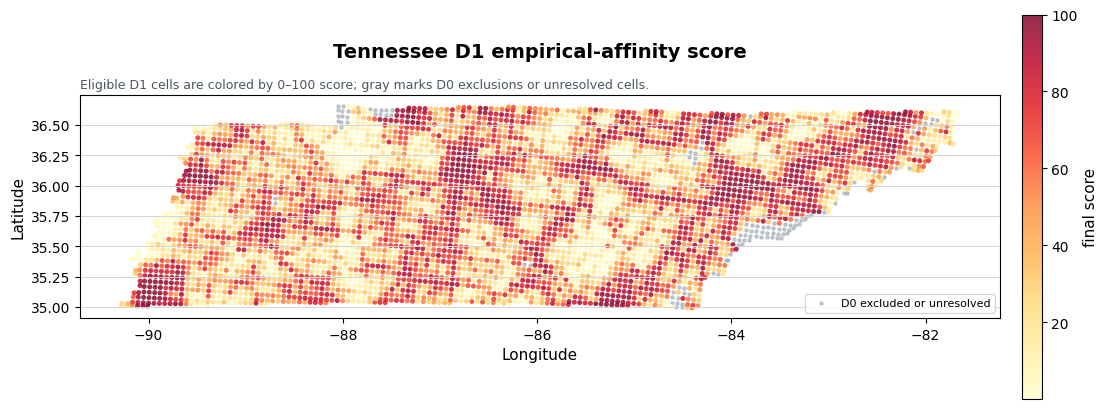

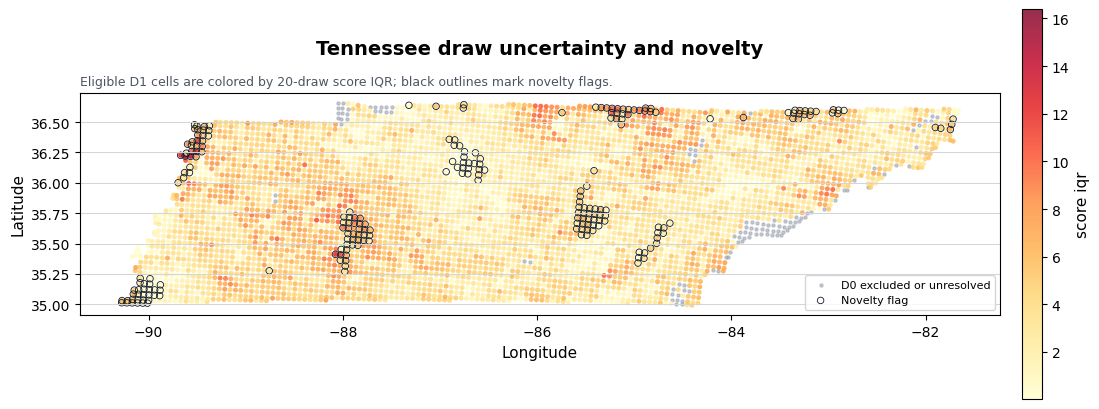

In [8]:
import json

release = build_release_lock(ROOT)
(RESULTS / f'{VERSION}_release_lock.json').write_text(json.dumps(release, indent=2) + '\n', encoding='utf-8')
rows, fields = build_statewide_product(ROOT)
with (RESULTS / f'{VERSION}_statewide_scores.csv').open('w', newline='', encoding='utf-8') as handle:
    import csv
    writer = csv.DictWriter(handle, fieldnames=fields); writer.writeheader(); writer.writerows(rows)
_ = build_products(ROOT)



## Candidate ranking and score distribution

The ranking chart pairs each Candidate's final score with its 20-draw P05–P95 interval. The scatter plot places uncertainty against score; outlined markers identify novelty flags.


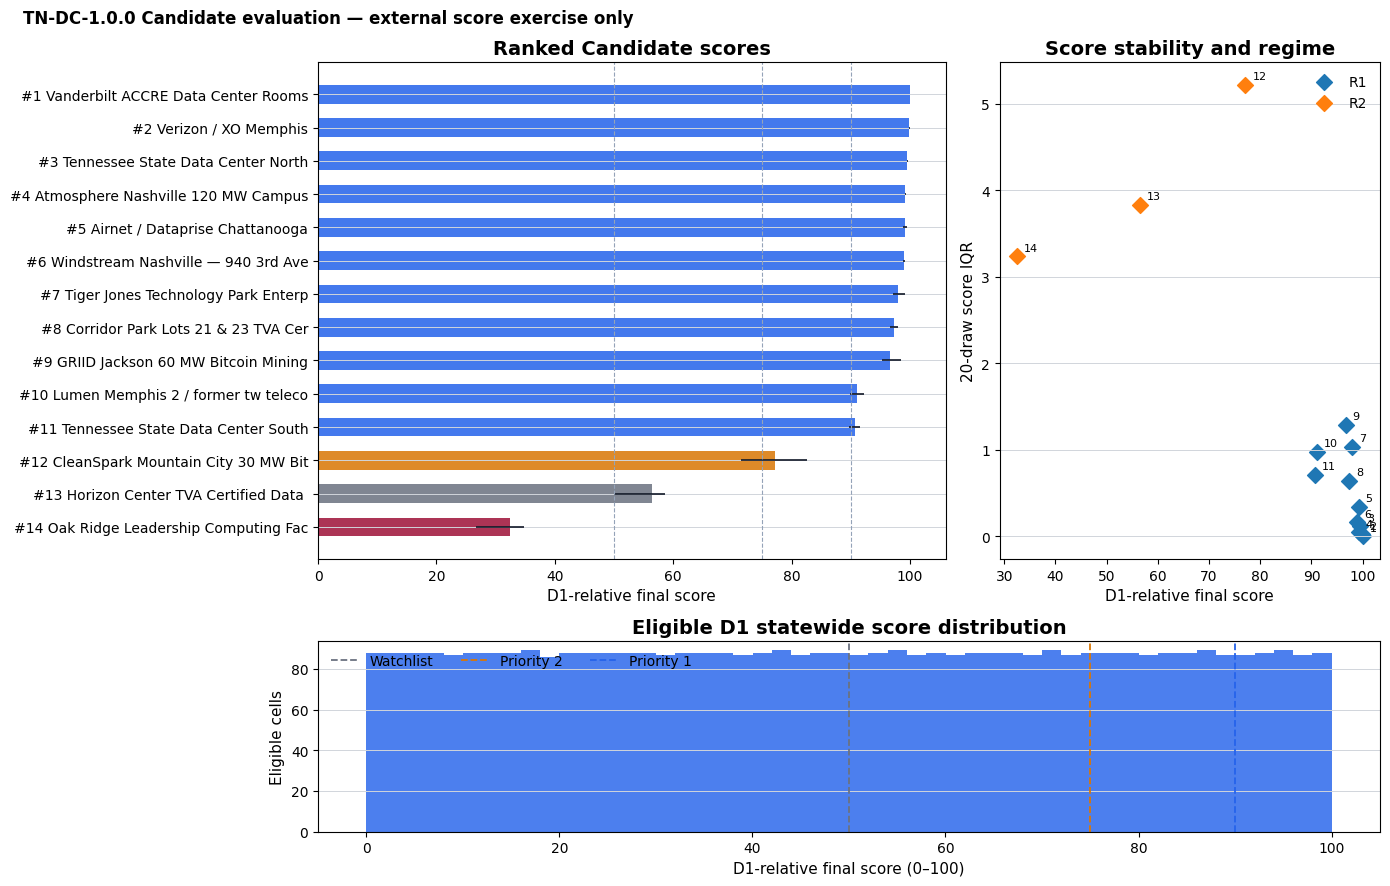

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

candidate_viz = pd.read_csv(RESULTS / f"{VERSION}_candidate_ranking.csv").sort_values("candidate_rank").copy()
statewide_viz = pd.read_csv(RESULTS / f"{VERSION}_statewide_scores.csv")
eligible_viz = statewide_viz.loc[statewide_viz["d1_status"].eq("eligible"), "final_score"].astype(float)
band_colors = {"Priority 1": "#2563eb", "Priority 2": "#d97706", "Watchlist": "#6b7280", "Lower empirical affinity": "#9f1239"}
apply_plot_theme(); figure = plt.figure(figsize=(14, 9)); grid = figure.add_gridspec(2, 2, height_ratios=[3, 1.15], width_ratios=[1.65, 1])
rank_axis, stability_axis, distribution_axis = figure.add_subplot(grid[0, 0]), figure.add_subplot(grid[0, 1]), figure.add_subplot(grid[1, :])
ordered = candidate_viz.iloc[::-1]
for _, row in ordered.iterrows():
    y = list(ordered.index).index(row.name)
    rank_axis.hlines(y, row.score_p05, row.score_p95, color='#111827', linewidth=1.2)
    rank_axis.barh(y, row.final_score, color=band_colors[row.review_band], alpha=.86, height=.56)
rank_axis.set(yticks=range(len(ordered)), yticklabels=[f"#{int(row.candidate_rank)} {str(row.site_name)[:34]}" for _, row in ordered.iterrows()], xlim=(0, 106), xlabel='D1-relative final score', title='Ranked Candidate scores')
for value in (50, 75, 90): rank_axis.axvline(value, color='#94a3b8', linestyle='--', linewidth=.8)
for regime_label, part in candidate_viz.groupby('grid_regime'):
    marker = 'D' if part.novelty_flag.astype(str).str.lower().eq('true').any() else 'o'
    stability_axis.scatter(part.final_score, part.score_iqr, label=regime_label, marker=marker, s=65)
for _, row in candidate_viz.iterrows(): stability_axis.annotate(str(int(row.candidate_rank)), (row.final_score, row.score_iqr), xytext=(5, 4), textcoords='offset points', fontsize=8)
stability_axis.set(title='Score stability and regime', xlabel='D1-relative final score', ylabel='20-draw score IQR'); stability_axis.legend(frameon=False)
distribution_axis.hist(eligible_viz, bins=50, color=PALETTE['blue'], alpha=.82)
for value, label, color in [(50, 'Watchlist', '#6b7280'), (75, 'Priority 2', '#d97706'), (90, 'Priority 1', '#2563eb')]: distribution_axis.axvline(value, color=color, linestyle='--', linewidth=1.3, label=label)
distribution_axis.set(title='Eligible D1 statewide score distribution', xlabel='D1-relative final score (0–100)', ylabel='Eligible cells'); distribution_axis.legend(frameon=False, ncol=3)
figure.suptitle(f'{VERSION} Candidate evaluation — external score exercise only', x=.02, ha='left', weight='bold'); finish_figure(figure, RESULTS / f'{VERSION}_candidate_dashboard.png')


## Statewide score distribution

This view shows the released D1 score distribution and the transparent review-band thresholds. D0 excluded or unresolved cells are intentionally absent because they have no score.


The statewide score distribution is included in the Matplotlib dashboard above.


## Retained regression-test source

The original test modules are preserved below as notebook cells. The final checks exercise the same public contracts without relying on deleted script paths.


## Final contract checks


In [10]:
manifest = build_release_lock(ROOT)
assert manifest['release_scope'] == 'primary_only'
assert manifest['feature_count'] == 21
assert manifest['primary_draw_count'] == 20
ranking = pd.read_csv(RESULTS / f'{VERSION}_candidate_ranking.csv')
assert len(ranking) == 14
assert ranking['candidate_rank'].tolist() == list(range(1, 15))
assert ranking['final_score'].between(0, 100).all()
assert (RESULTS / f'{VERSION}_score_map.png').exists()
assert (RESULTS / f'{VERSION}_uncertainty_novelty_map.png').exists()
print('Phase 4 release, scoring, ranking, and map checks passed.')


Phase 4 release, scoring, ranking, and map checks passed.


## 4E — verification and release gate

This check writes one retained release-verification record. Its batch fixtures exist only inside a temporary directory and are removed automatically.


In [11]:
import csv
import tempfile


def verify_release_gate(project_root: Path) -> dict:
    release = build_release_lock(project_root)
    phase2 = project_root / release["artifacts"]["phase2_dataset"]["path"]
    features = release["features"]
    candidates = [row for row in xlsx_records(phase2, "Presence_Sites") if row["record_role"] == "candidate"]
    if len(candidates) != 14:
        raise AssertionError("Phase 2 Candidate count is not 14")

    seed = candidates[0]
    shared = {feature: seed[feature] for feature in features}
    metadata = {"location_name": seed["site_name"], "latitude": seed["latitude"], "longitude": seed["longitude"]}
    with tempfile.TemporaryDirectory() as temporary:
        batch_path = Path(temporary) / "batch.csv"
        fieldnames = ["location_id", *metadata, *features]
        with batch_path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows([
                {"location_id": "one", **metadata, **shared},
                {"location_id": "batch-copy", **metadata, **shared},
            ])
        batch_rows, _ = score_batch(project_root, batch_path)
        one_path = Path(temporary) / "one.csv"
        with one_path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerow({"location_id": "one", **metadata, **shared})
        one_rows, _ = score_batch(project_root, one_path)
    if float(batch_rows[0]["final_score"]) != float(one_rows[0]["final_score"]):
        raise AssertionError("Batch and one-row scoring differ")

    vector = [float(shared[feature]) for feature in features]
    baseline, _ = score_vectors(project_root, [{"location_id": "metadata-baseline"}], [vector], ["location_id"], release)
    altered, _ = score_vectors(
        project_root,
        [{"location_id": "different-id", "latitude": "0", "longitude": "0", "grand_region": "east", "cell_id": "other", "record_role": "primary", "grid_regime": "R2"}],
        [vector],
        ["location_id", "latitude", "longitude", "grand_region", "cell_id", "record_role", "grid_regime"],
        release,
    )
    for field in ("final_raw_score", "final_score", "score_p05", "score_p95", "score_iqr", "grid_regime", "regime_distance", "novelty_flag"):
        if baseline[0][field] != altered[0][field]:
            raise AssertionError(f"Prohibited metadata affected scorer: {field}")

    with (RESULTS / f"{VERSION}_statewide_scores.csv").open(newline="", encoding="utf-8") as handle:
        statewide = list(csv.DictReader(handle))
    eligible = [row for row in statewide if row["d1_status"] == "eligible"]
    excluded = [row for row in statewide if row["d1_status"] != "eligible"]
    if len(statewide) != 4502 or len(eligible) != 4391 or len({row["cell_id"] for row in eligible}) != 4391:
        raise AssertionError("Statewide D0/D1 cell counts or IDs do not reconcile")
    if not all(0 <= float(row["final_score"]) <= 100 for row in eligible):
        raise AssertionError("An eligible D1 score is outside 0–100")
    if any(row["final_score"] for row in excluded):
        raise AssertionError("A D0 excluded or unresolved row has a score")

    with (RESULTS / f"{VERSION}_candidate_ranking.csv").open(newline="", encoding="utf-8") as handle:
        candidate_csv = list(csv.DictReader(handle))
    candidate_xlsx = xlsx_records(RESULTS / f"{VERSION}_candidate_ranking.xlsx", "Candidate details")
    if len(candidate_csv) != 14 or len(candidate_xlsx) != 14:
        raise AssertionError("Candidate table count does not reconcile")
    csv_scores = {row["site_id"]: float(row["final_score"]) for row in candidate_csv}
    xlsx_scores = {row["site_id"]: float(row["final_score"]) for row in candidate_xlsx}
    if csv_scores != xlsx_scores:
        raise AssertionError("Candidate CSV and workbook scores do not reconcile")
    if {row["record_role"] for row in candidate_csv} != {"candidate"}:
        raise AssertionError("Candidate table includes non-Candidate training rows")
    for name in (f"{VERSION}_score_map.png", f"{VERSION}_uncertainty_novelty_map.png"):
        if not (RESULTS / name).is_file():
            raise AssertionError(f"Missing Matplotlib map: {name}")

    return {
        "status": "pass",
        "statewide_cells": len(statewide),
        "eligible_d1_cells": len(eligible),
        "excluded_or_unresolved_cells": len(excluded),
        "candidate_rows": len(candidate_csv),
        "score_min": min(float(row["final_score"]) for row in eligible),
        "score_max": max(float(row["final_score"]) for row in eligible),
    }


verification = verify_release_gate(ROOT)
report = RESULTS / f"{VERSION}_release_verification.md"
report.write_text(
    f"# {VERSION} release verification\n\n"
    f"Status: **{verification['status'].upper()}**\n\n"
    f"- Phase 2 hash, feature order, selected model, and 20 Primary draws reconcile with the frozen package.\n"
    f"- Batch and one-row scores agree for the same vector.\n"
    f"- {verification['statewide_cells']:,} statewide cells reconcile to {verification['eligible_d1_cells']:,} eligible D1 and {verification['excluded_or_unresolved_cells']:,} excluded or unresolved rows.\n"
    f"- Eligible scores range from {verification['score_min']:.6f} to {verification['score_max']:.6f}; D0 rows carry no score.\n"
    f"- {verification['candidate_rows']} Candidate rows reconcile across CSV and workbook; Candidate records remain external to Primary training.\n"
    f"- Score and uncertainty/novelty maps include the D0 exclusion legend.\n",
    encoding="utf-8",
)
print(report)
verification


/Users/steve/Project/UTK/outputs/Data center/TN/model/phase 4/results/TN-DC-1.0.0_release_verification.md


{'status': 'pass',
 'statewide_cells': 4502,
 'eligible_d1_cells': 4391,
 'excluded_or_unresolved_cells': 111,
 'candidate_rows': 14,
 'score_min': 0.0227738556138,
 'score_max': 100.0}